In [1]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [2]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [3]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output, plot_ldos
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\min

In [4]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'Gamma'
quantum_band_interactions = r'Gamma_Gamma'

C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_minibands_7p5nm_2p5nm_Nwell_sweep_nnp\bias_00000\OpticsQuantum\quantum_region


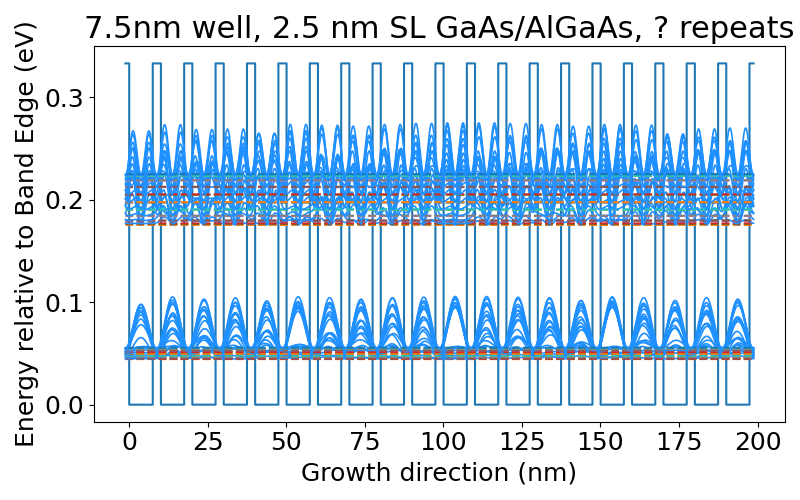


Intersubband transition energies — CB
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
 18 → 19 | -0.0001
 16 → 17 | -0.0001
 14 → 15 | -0.0001
 12 → 13 | -0.0001
 10 → 11 | -0.0001
  8 →  9 | -0.0001
  2 →  3 | -0.0001
  6 →  7 | -0.0001
  4 →  5 | -0.0001
 38 → 39 | -0.0002
 36 → 37 | -0.0003
  1 →  2 | -0.0003
 34 → 35 | -0.0003
 19 → 20 | -0.0003
 32 → 33 | -0.0003
 30 → 31 | -0.0003
 18 → 20 | -0.0004
 28 → 29 | -0.0004
 26 → 27 | -0.0004
  1 →  3 | -0.0004
 22 → 23 | -0.0004
 24 → 25 | -0.0004
  3 →  4 | -0.0006
  2 →  4 | -0.0007
  3 →  5 | -0.0007
  2 →  5 | -0.0008
 17 → 18 | -0.0009
 17 → 19 | -0.0009
 16 → 18 | -0.0009
  1 →  4 | -0.0009
  5 →  6 | -0.0010
 16 → 19 | -0.0010
 21 → 22 | -0.0010
  1 →  5 | -0.0011
  5 →  7 | -0.0011
  4 →  6 | -0.0011
  4 →  7 | -0.0012
 17 → 20 | -0.0012
 16 → 20 | -0.0013
 15 → 16 | -0.0013
  7 →  8 | -0.0013
 15 → 17 | -0.0014
 14 → 16 | -0.0014
  7 →  9 | -0.0014


In [12]:
%matplotlib widget
parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1DSL_minibands_7p5nm_2p5nm_Nwell_sweep_nnp"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\1Dsuperlattice_5nm_well_Nsweep_nnp(4)"
# parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\confirming_dipole_matrix_elements_expected(6)"

VB_cutoff = 2.0
simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,VB_cutoff,14,model='gamma')
simoutidk.bands['CB'].sort_subbands(decreasing=False)

simoutidk.bands['CB'].plot_band(title_diff='7.5nm well, 2.5 nm SL GaAs/AlGaAs, ? repeats',normalize_y=True,show_legend=False)
# simoutidk.bands['CB'].plot_band(title_diff='10nm SW GaAs/AlGaAs',normalize_y=False,show_legend=True)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")


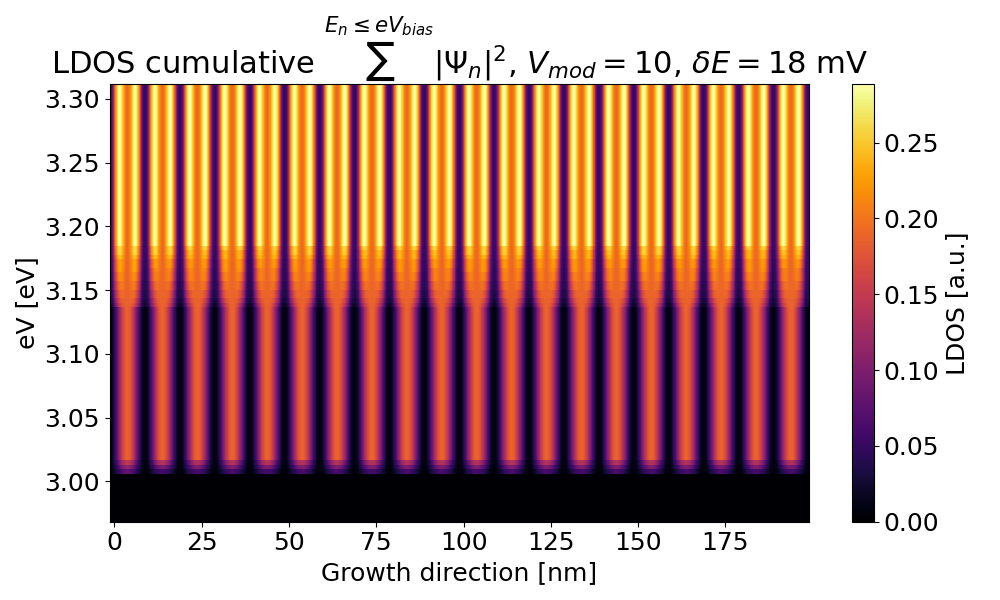

<Axes: title={'center': 'LDOS cumulative $\\sum^{E_n \\leq eV_{bias}} {|\\Psi_n|}^2$, $V_{mod}=10$, $\\delta E=18$ mV'}, xlabel='Growth direction [nm]', ylabel='eV [eV]'>

In [6]:
%matplotlib widget
eVbias = np.linspace(2.97, 3.31, 100)
Vmod = 0.01 #V 
Ebroad = Vmod*1.8
ldos = simoutidk.bands['CB'].calc_ldos(eVbias,deltaE=Ebroad)
# plot_ldos(simoutidk.bands['CB'], ldos, eVbias,title_diff=r'LDOS cumulative $\sum^{E_n <=eV_{bias}} {|\Psi_n|}^2$')
plot_ldos(simoutidk.bands['CB'], ldos, eVbias,title_diff=rf'LDOS cumulative $\sum^{{E_n \leq eV_{{bias}}}} {{|\Psi_n|}}^2$, $V_{{mod}}={Vmod*1000:.0f}$, $\delta E={Ebroad*1000:.0f}$ mV')


In [7]:
eVbias
summed_probabdist = np.zeros_like(simoutidk.bands['CB'].subbands[0].probab_dist)
for subbands in simoutidk.bands['CB'].subbands:
    summed_probabdist += subbands.probab_dist

plt.plot(simoutidk.bands['CB'].x, summed_probabdist)

In [8]:
simoutidk.bands['CB'].subbands

[<Eigenstate #index=1, energy=3.023056608624 eV>,
 <Eigenstate #index=2, energy=3.023332291731 eV>,
 <Eigenstate #index=3, energy=3.023436757336 eV>,
 <Eigenstate #index=4, energy=3.023997056752 eV>,
 <Eigenstate #index=5, energy=3.024108529491 eV>,
 <Eigenstate #index=6, energy=3.025073634762 eV>,
 <Eigenstate #index=7, energy=3.025182375758 eV>,
 <Eigenstate #index=8, energy=3.02648378448 eV>,
 <Eigenstate #index=9, energy=3.026587001891 eV>,
 <Eigenstate #index=10, energy=3.028122592443 eV>,
 <Eigenstate #index=11, energy=3.028218210985 eV>,
 <Eigenstate #index=12, energy=3.029850903869 eV>,
 <Eigenstate #index=13, energy=3.029937157774 eV>,
 <Eigenstate #index=14, energy=3.03149757515 eV>,
 <Eigenstate #index=15, energy=3.031573209371 eV>,
 <Eigenstate #index=16, energy=3.032871847373 eV>,
 <Eigenstate #index=17, energy=3.032936590996 eV>,
 <Eigenstate #index=18, energy=3.033790995616 eV>,
 <Eigenstate #index=19, energy=3.033845414669 eV>,
 <Eigenstate #index=20, energy=3.034143984